## Resources

This notebook performs data loading, cleaning, preprocessing, model training, and evaluation for a depression prediction task.

In [ ]:
import pandas as pd
import numpy as np


This cell imports the necessary libraries: `pandas` for data manipulation and `numpy` for numerical operations.

In [ ]:
train = pd.read_csv('/content/train.csv')

This cell loads the `train.csv` dataset into a pandas DataFrame named `train`.

In [ ]:
train.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


This cell displays the first 5 rows of the `train` DataFrame to get an initial look at the data.

In [ ]:
train.isnull().sum()

,0
id,0
Name,0
Gender,0
Age,0
City,0
Working Professional or Student,0
Profession,36630
Academic Pressure,112803
Work Pressure,27918
CGPA,112802


This cell calculates and displays the count of missing values for each column in the `train` DataFrame.

In [ ]:
train['Depression'].value_counts(normalize=True)*100

,proportion
Depression,
0,81.828714
1,18.171286


This cell shows the percentage distribution of the 'Depression' target variable, indicating the class imbalance.

In [ ]:
train['Profession'].value_counts(normalize=True)*100

,proportion
Profession,
Teacher,23.931969
Content Writer,7.508408
Architect,4.199097
Consultant,4.063611
HR Manager,3.864706
...,...
Moderate,0.000961
Analyst,0.000961
Pranav,0.000961


This cell shows the percentage distribution of the 'Profession' column to understand its categories.

In [ ]:
null = (train.isnull().mean() * 100).sort_values(ascending=False)
print(null)

Study Satisfaction                       80.172708
Academic Pressure                        80.172708
CGPA                                     80.171997
Profession                               26.034115
Work Pressure                            19.842217
Job Satisfaction                         19.836532
Financial Stress                          0.002843
Dietary Habits                            0.002843
Degree                                    0.001421
Gender                                    0.000000
Name                                      0.000000
id                                        0.000000
Age                                       0.000000
City                                      0.000000
Working Professional or Student           0.000000
Sleep Duration                            0.000000
Have you ever had suicidal thoughts ?     0.000000
Work/Study Hours                          0.000000
Family History of Mental Illness          0.000000
Depression                     

This cell calculates and prints the percentage of null values for all columns, sorted in descending order, to identify columns with significant missing data.

In [ ]:
train.drop("Study Satisfaction", axis=1, inplace=True)

This cell drops the 'Study Satisfaction' column due to a high percentage of missing values (over 80%).

In [ ]:
train.drop("Academic Pressure", axis=1, inplace=True)

This cell drops the 'Academic Pressure' column, also due to a high percentage of missing values (over 80%).

In [ ]:
train.drop("CGPA", axis=1, inplace=True)

This cell drops the 'CGPA' column, which also had a very high percentage of missing values (over 80%).

In [ ]:
null1 = (train.isnull().mean() * 100).sort_values(ascending=False)
print(null1)

Profession                               26.034115
Work Pressure                            19.842217
Job Satisfaction                         19.836532
Financial Stress                          0.002843
Dietary Habits                            0.002843
Degree                                    0.001421
id                                        0.000000
City                                      0.000000
Name                                      0.000000
Working Professional or Student           0.000000
Gender                                    0.000000
Age                                       0.000000
Sleep Duration                            0.000000
Have you ever had suicidal thoughts ?     0.000000
Work/Study Hours                          0.000000
Family History of Mental Illness          0.000000
Depression                                0.000000
dtype: float64


This cell recalculates and prints the percentage of null values for each column after dropping the highly missing columns, to see the remaining missing data.

In [ ]:
train['Profession'] = train['Profession'].fillna('Unknown')
train['Work Pressure'] = train['Work Pressure'].fillna('Unknown')
train['Job Satisfaction'] = train['Job Satisfaction'].fillna('Unknown')
train['Financial Stress'] = train['Financial Stress'].fillna('Unknown')
train['Dietary Habits'] = train['Dietary Habits'].fillna('Unknown')
train['Degree'] = train['Degree'].fillna('Unknown')


This cell fills the remaining missing values in categorical columns ('Profession', 'Work Pressure', 'Job Satisfaction', 'Financial Stress', 'Dietary Habits', 'Degree') with the string 'Unknown'.

In [ ]:
null2 = (train.isnull().mean() * 100).sort_values(ascending=False)
print(null2)

id                                       0.0
Name                                     0.0
Gender                                   0.0
Age                                      0.0
City                                     0.0
Working Professional or Student          0.0
Profession                               0.0
Work Pressure                            0.0
Job Satisfaction                         0.0
Sleep Duration                           0.0
Dietary Habits                           0.0
Degree                                   0.0
Have you ever had suicidal thoughts ?    0.0
Work/Study Hours                         0.0
Financial Stress                         0.0
Family History of Mental Illness         0.0
Depression                               0.0
dtype: float64


This cell verifies that all null values have been handled by re-calculating and printing the percentage of null values for all columns. It should show 0% for all.

In [ ]:
train.isnull().sum()

,0
id,0
Name,0
Gender,0
Age,0
City,0
Working Professional or Student,0
Profession,0
Work Pressure,0
Job Satisfaction,0
Sleep Duration,0


This cell further confirms that there are no remaining missing values in the DataFrame by summing them up.

In [ ]:
train.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,5.0,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,4.0,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,Unknown,Unknown,Unknown,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,5.0,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,1.0,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


This cell displays the first 5 rows of the DataFrame after handling all missing values, showing the 'Unknown' entries.

In [ ]:
cat_cols=train.select_dtypes(include="object").columns

cat_cols

Index(['Name', 'Gender', 'City', 'Working Professional or Student',
       'Profession', 'Work Pressure', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?',
       'Financial Stress', 'Family History of Mental Illness'],
      dtype='object')

This cell identifies and stores the names of all categorical columns (columns with 'object' data type) in the `cat_cols` variable.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train[col] = train[col].astype(str)
    train[col] = le.fit_transform(train[col])
    label_encoders[col] = le
train.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,11,0,49.0,50,1,10,4,1,29,7,33,0,1.0,1,0,0
1,1,407,1,26.0,93,1,55,3,2,27,20,63,1,7.0,2,0,1
2,2,417,1,33.0,97,0,59,5,5,15,7,21,1,3.0,0,0,1
3,3,417,1,22.0,64,1,55,4,0,27,15,28,1,10.0,0,1,1
4,4,286,0,30.0,37,1,9,0,0,15,20,28,1,9.0,3,1,0


This cell applies `LabelEncoder` from `sklearn.preprocessing` to convert all identified categorical columns into numerical representations. It then displays the first few rows of the DataFrame with the encoded values.

In [ ]:
from imblearn.over_sampling import SMOTE

X = train.drop("Depression", axis=1)
y = train["Depression"]

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

This cell addresses the class imbalance in the target variable ('Depression') using SMOTE (Synthetic Minority Over-sampling Technique) to create a balanced dataset for training.

In [ ]:
from collections import Counter

print(Counter(y_resampled))

Counter({0: 115133, 1: 115133})


This cell prints the distribution of the target variable (`y_resampled`) after applying SMOTE, confirming that the classes are now balanced.

In [ ]:
y_resampled.value_counts()

,count
Depression,
0,115133
1,115133


This cell provides another way to verify the balanced class distribution of the resampled target variable using `value_counts()`.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


This cell imports `seaborn` and `matplotlib.pyplot`, which are libraries commonly used for data visualization.

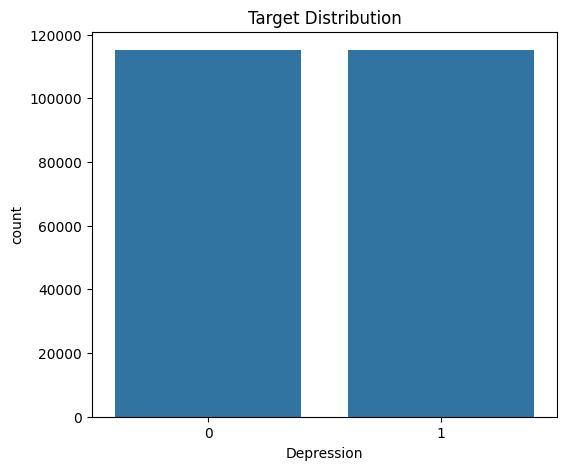

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x=y_resampled)

plt.title("Target Distribution")

plt.show()

This cell generates a countplot to visualize the distribution of the resampled target variable, showing the balanced classes.

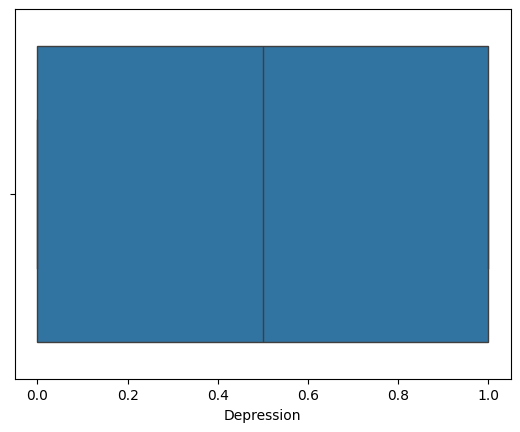

In [ ]:
sns.boxplot(x=y_resampled)
plt.show()

This cell creates a boxplot of the resampled target variable. While less informative for binary data, it's included as part of the visual exploration.

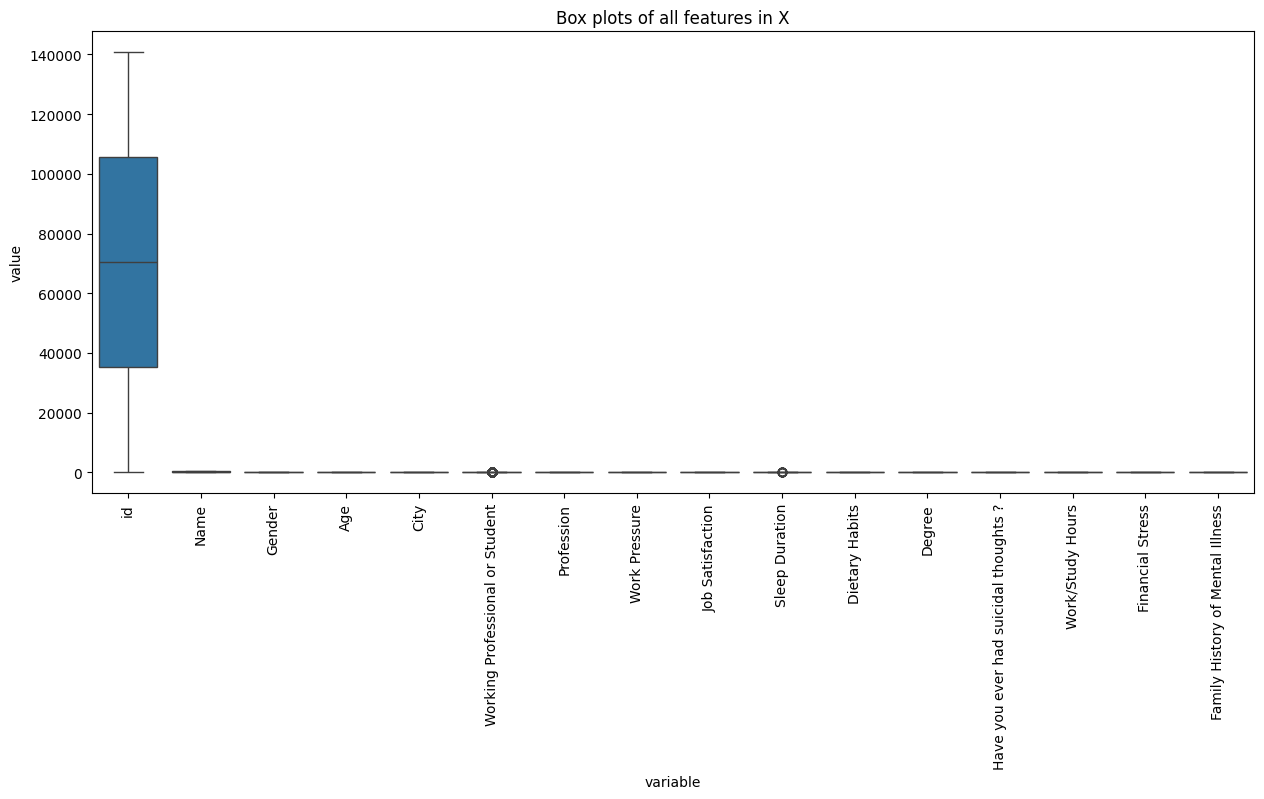

In [ ]:
X_melted = X.melt()
plt.figure(figsize=(15, 6))
sns.boxplot(data=X_melted, x='variable', y='value')
plt.xticks(rotation=90)
plt.title('Box plots of all features in X')
plt.show()

This cell generates box plots for all features in the `X` (features) DataFrame to visualize their distributions, spread, and identify potential outliers.

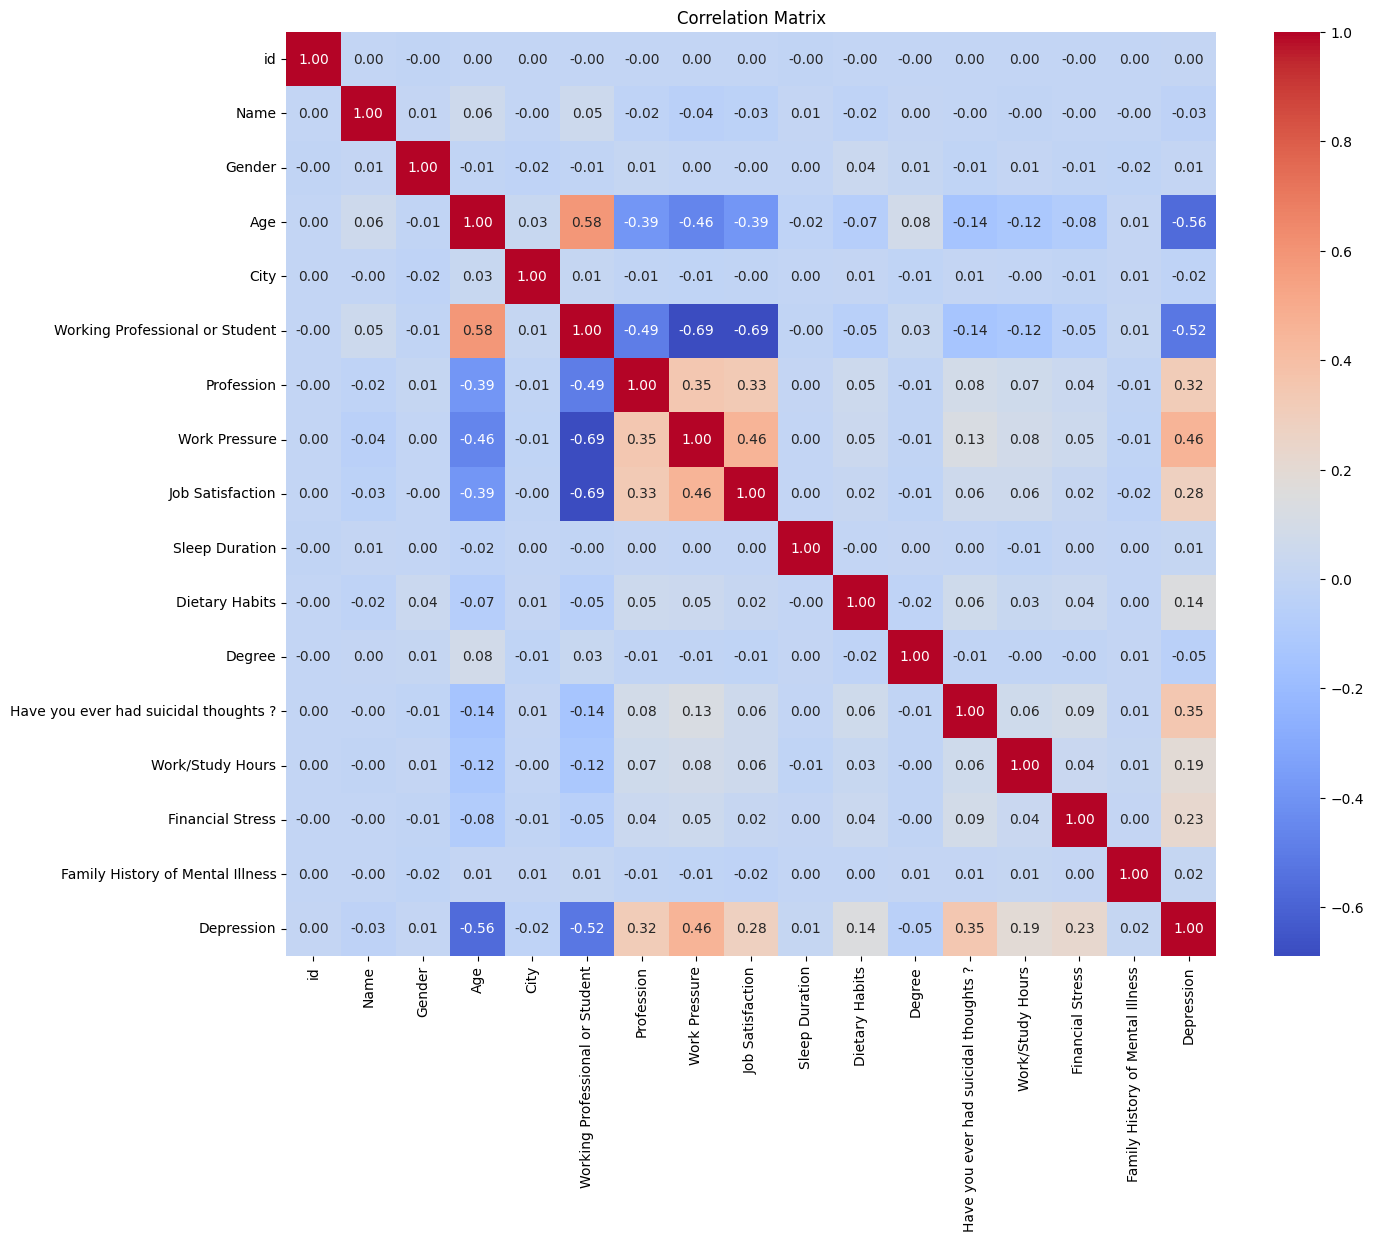

In [ ]:
df_resampled = pd.concat([pd.DataFrame(X), pd.DataFrame(y)], axis=1)

corr_matrix = df_resampled.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

This cell computes and displays a correlation matrix as a heatmap for all features and the target variable in the resampled dataset. This helps in understanding relationships between variables.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

This cell splits the resampled dataset (`X_resampled`, `y_resampled`) into training and testing sets using a 80/20 ratio, ensuring reproducibility with `random_state=42`.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

This cell initializes and trains a `RandomForestClassifier` model with 100 estimators and a fixed random state, using the training data.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

pred = rf_model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy : 0.9520997090372172
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     23005
           1       0.95      0.96      0.95     23049

    accuracy                           0.95     46054
   macro avg       0.95      0.95      0.95     46054
weighted avg       0.95      0.95      0.95     46054



This cell uses the trained Random Forest model to make predictions on the test set (`X_test`) and then prints the accuracy score and a detailed classification report (precision, recall, f1-score) for evaluation.

In [ ]:
!pip install catboost

This cell installs the `catboost` library, which is another powerful gradient boosting framework for classification.

In [ ]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    verbose=100,
    random_state=42,
    task_type='GPU'
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("Accuracy (CatBoost):", accuracy_score(y_test, cat_pred))
print(classification_report(y_test, cat_pred))

0:	learn: 0.5369487	total: 121ms	remaining: 1m
100:	learn: 0.1160998	total: 1.33s	remaining: 5.25s
200:	learn: 0.1076629	total: 2.16s	remaining: 3.22s
300:	learn: 0.1036241	total: 6.39s	remaining: 4.22s
400:	learn: 0.1009968	total: 16.6s	remaining: 4.09s
499:	learn: 0.0986792	total: 21.8s	remaining: 0us
Accuracy (CatBoost): 0.9579841056151475
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     23005
           1       0.96      0.96      0.96     23049

    accuracy                           0.96     46054
   macro avg       0.96      0.96      0.96     46054
weighted avg       0.96      0.96      0.96     46054



This cell initializes and trains a `CatBoostClassifier` model with specified parameters (iterations, learning rate, depth, verbosity, and GPU support). It then makes predictions on the test set and prints the accuracy and classification report for evaluation.

In [ ]:
test_df = pd.DataFrame(
    {'True': y_test, 'Catboost': cat_pred, 'RandomForest': pred})

This cell creates a pandas DataFrame named `test_df` to store the true labels (`y_test`) and the predictions from both the CatBoost and Random Forest models, facilitating comparison.

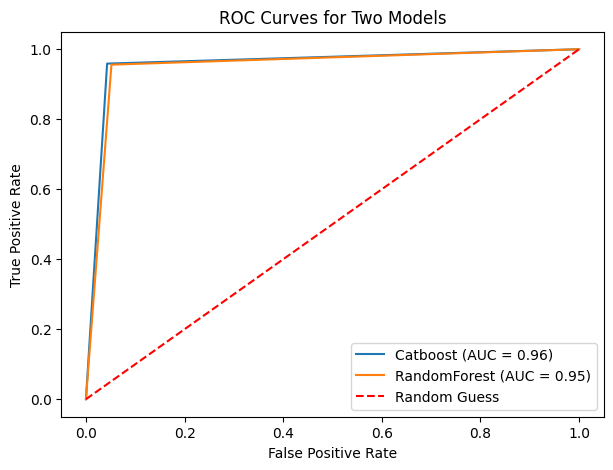

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 5))

for model in ['Catboost', 'RandomForest']:
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Two Models')
plt.legend()
plt.show()

This cell generates and plots ROC (Receiver Operating Characteristic) curves for both the CatBoost and Random Forest models. It calculates and displays the Area Under the Curve (AUC) for each model, which is a common metric for evaluating binary classifiers.

In [ ]:
import joblib

joblib.dump(cat_model, 'catboost_depression.pkl')

['catboost_depression.pkl']

This cell saves the trained CatBoost model to a file named `catboost_depression.pkl` using `joblib` for later use, without needing to retrain.

In [ ]:
import joblib

joblib.dump(label_encoders, 'label_encoders.pkl')

['label_encoders.pkl']

This cell saves the `label_encoders` dictionary (which contains all the fitted LabelEncoder objects for the categorical columns) to a file named `label_encoders.pkl` using `joblib`. This is important for inverse transforming or consistently encoding new data.